### P-center problem

The first mixed-integer programming (MIP) formulation for the discrete $p$-center problem was proposed by Daskin (2013). The following decision variables are defined:  
$y_i = 1$ if a facility is located at node $i \in I$, and $0$ otherwise;  
$x_{ij} = 1$ if customer $j \in J$ is assigned to a facility located at node $i \in I$, and $0$ otherwise.  

Daskin’s formulation can be expressed as follows:

$$
\begin{aligned}
\text{Min} \quad & z \\
\text{subject to} \quad
& \sum_{i \in I} d_{ji} x_{ij} \leq z, \quad \forall j \in J, \\
& \sum_{i \in I} x_{ij} = 1, \quad \forall j \in J, \\
& x_{ij} \leq y_i, \quad \forall i \in I,\; j \in J, \\
& \sum_{i \in I} y_i \leq p, \\
& y_i \in \{0,1\}, \quad \forall i \in I, \\
& x_{ij} \in \{0,1\}, \quad \forall i \in I,\; j \in J.
\end{aligned}
$$

In [ ]:
%pip install gurobipy
from gurobipy import Model, GRB, quicksum
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 21.5 MB/s eta 0:00:00


In [ ]:
# Number of candidate facility sites
num_facilities = 5

# Number of customers
num_customers = 5

# Sets
I = range(num_facilities)
J = range(num_customers)

# Symmetric service cost matrix
c = np.array([[0, 3, 3, 6, 3],
              [3, 0, 4, 5, 5],
              [3, 4, 0, 2, 4],
              [6, 5, 2, 0, 5],
              [3, 5, 4, 5, 0]])

# Customer demand
d = np.array([10, 8, 5, 8, 12])

# Number of facilities to locate
p = 2

In [ ]:
# Define model
m = Model("p-center")

# Decision variables
x = m.addVars(I, J, vtype=GRB.BINARY, name="x")
y = m.addVars(I, vtype=GRB.BINARY, name="y")
z = m.addVar(vtype=GRB.CONTINUOUS, name="z")

# Objective function
m.setObjective(z, GRB.MINIMIZE)

# Constraints
m.addConstrs(quicksum(x[i,j] for i in I) == 1 for j in J)
m.addConstr(quicksum(y[i] for i in I) <= p)
m.addConstrs(x[i,j] - y[i] <= 0 for i in I for j in J)
m.addConstrs(quicksum(c[i,j]*x[i,j] for i in I) <= z for j in J)

# Optimize
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 36 rows, 31 columns and 105 nonzeros (Min)
Model fingerprint: 0x8804d64c
Model has 1 linear objective coefficients
Variable types: 1 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Found heuristic solution: objective 5.0000000
Presolve removed 2 rows and 2 columns
Presolve time: 0.00s
Presolved: 34 rows, 29 columns, 95 nonzeros
Variable types: 0 continuous, 29 integer (28 binary)

Root relaxation: objective 2.250000e+00, 18 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    B

In [ ]:
if m.status == GRB.OPTIMAL:
    print("Optimal solution")
    print("Total cost: ", m.objVal)
    for i in I:
      if y[i].X > 0.1:
          print("Open facility: ", i)
else:
    print("There is not optimal solution")

Optimal solution
Total cost:  3.0
Open facility:  0
Open facility:  2


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle



def solve_and_plot_p_center(num_facilities=5, num_customers=5, p=2, seed=42,
                            coord_range=(0, 100), metric="euclidean"):
    rng = np.random.default_rng(seed)

    I = range(num_facilities)
    J = range(num_customers)

    facilities_xy = rng.uniform(coord_range[0], coord_range[1], size=(num_facilities, 2))
    customers_xy = rng.uniform(coord_range[0], coord_range[1], size=(num_customers, 2))

    if metric.lower() == "euclidean":
        diff = facilities_xy[:, None, :] - customers_xy[None, :, :]
        c = np.sqrt((diff ** 2).sum(axis=2))
    elif metric.lower() == "manhattan":
        diff = np.abs(facilities_xy[:, None, :] - customers_xy[None, :, :])
        c = diff.sum(axis=2)
    else:
        raise ValueError("metric must be 'euclidean' or 'manhattan'")

    m = Model("p-center")
    x = m.addVars(I, J, vtype=GRB.BINARY, name="x")
    y = m.addVars(I, vtype=GRB.BINARY, name="y")
    z = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, name="z")

    m.setObjective(z, GRB.MINIMIZE)

    m.addConstrs((quicksum(x[i, j] for i in I) == 1 for j in J))
    m.addConstr(quicksum(y[i] for i in I) == p)
    m.addConstrs((x[i, j] <= y[i] for i in I for j in J))
    m.addConstrs((c[i, j] * x[i, j] <= z for i in I for j in J))
    m.optimize()

    open_facilities = [i for i in I if y[i].X > 0.5]
    assignments = {}  # j -> i
    total_distance = 0.0
    min_dist = float("inf")
    max_dist = 0.0

    for j in J:
        i_star = None
        for i in I:
            if x[i, j].X > 0.5:
                i_star = i
                break
        assignments[j] = i_star
        dist = float(c[i_star, j])
        total_distance += dist
        min_dist = min(min_dist, dist)
        max_dist = max(max_dist, dist)

    print(f"Total distance traveled by all customers: {total_distance:.4f}")
    print(f"Minimum distance traveled by a customer: {min_dist:.4f}")
    print(f"Maximum assigned distance (z): {z.X:.4f}")
    for i in open_facilities:
        print("Open facility at:", i)

    fig, ax = plt.subplots(figsize=(9, 7))

    # Customers
    ax.scatter(customers_xy[:, 0], customers_xy[:, 1], marker="o")
    for j in J:
        ax.annotate(f"C{j}", (customers_xy[j, 0], customers_xy[j, 1]),
                    xytext=(5, 5), textcoords="offset points")

    # Closed facilities
    closed_facilities = [i for i in I if i not in open_facilities]
    if closed_facilities:
        ax.scatter(facilities_xy[closed_facilities, 0], facilities_xy[closed_facilities, 1], marker="s")
        for i in closed_facilities:
            ax.annotate(f"F{i}", (facilities_xy[i, 0], facilities_xy[i, 1]),
                        xytext=(5, 5), textcoords="offset points")

    # Open facilities (highlighted) + circles with radius z
    if open_facilities:
        ax.scatter(facilities_xy[open_facilities, 0], facilities_xy[open_facilities, 1], marker="s")
        for i in open_facilities:
            ax.annotate(f"F{i}*", (facilities_xy[i, 0], facilities_xy[i, 1]),
                        xytext=(5, 5), textcoords="offset points")
            circ = Circle((facilities_xy[i, 0], facilities_xy[i, 1]), radius=float(z.X),
                          fill=False, linewidth=1.5)
            ax.add_patch(circ)

    # Assignment lines
    for j, i in assignments.items():
        x0, y0 = customers_xy[j, 0], customers_xy[j, 1]
        x1, y1 = facilities_xy[i, 0], facilities_xy[i, 1]
        ax.plot([x0, x1], [y0, y1], linewidth=1)

    ax.set_title(f"p-center solution (p={p}) - z={z.X:.4f} - metric: {metric}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return m



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 621 rows, 316 columns and 1515 nonzeros (Min)
Model fingerprint: 0xdc23f7e0
Model has 1 linear objective coefficients
Variable types: 1 continuous, 315 integer (315 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]

Presolve removed 280 rows and 0 columns
Presolve time: 0.01s
Presolved: 341 rows, 316 columns, 1198 nonzeros
Variable types: 1 continuous, 315 integer (315 binary)
Found heuristic solution: objective 87.2882832
Found heuristic solution: objective 87.2681003
Found heuristic solution: objective 69.4996183
Found heuristic solution: objective 61.8059779

Root relaxation: objective 2.555972e+01, 152 iterations,

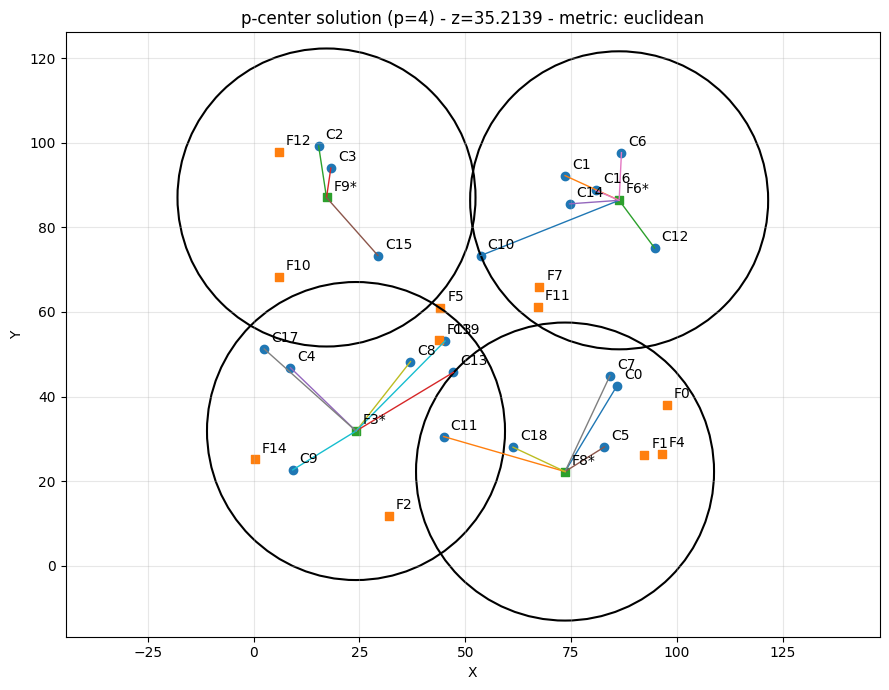

<gurobi.Model MIP instance p-center: 621 constrs, 316 vars, No parameter changes>

In [ ]:
solve_and_plot_p_center(num_facilities=15, num_customers=20, p = 4 ,seed=1234, metric="euclidean")